# Lane Theory 02: Modeling & Optimization (v3)
One benchmark model per gender, predicting final_time_sec directly (no
ranking, no height clustering). SHAP identifies which technique/pacing
features matter most. Constrained optimization simulates a performance
range associated with elite-benchmark primitive values. All outputs are
ranges, never single-point targets.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

sys.path.insert(0, "../src")
from optimization import (
    primitive_cols, derived_cols, feature_cols,
    get_gender_bounds, get_gender_range_summary, get_top_levers,
    optimize_swimmer, diagnose_swimmer, print_report,
)

from sklearn.ensemble import RandomForestRegressor
import shap

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

In [2]:
print(feature_cols)
print("intra_lap1_fade_ratio" in feature_cols)

['l1_reaction_time', 'l1_underwater_speed', 'l2_underwater_speed', 'l1_relative_stroke_length', 'l2_relative_stroke_length', 'l1_stroke_rate', 'l2_stroke_rate', 'pacing_decay_ratio', 'si_retention', 'breakout_decay_ratio', 'surface_speed_decay_ratio', 'front_end_pct', 'relative_stroke_length_drop', 'stroke_rate_change', 'swolf_change', 'breakout_drop', 'intra_lap1_fade_ratio', 'intra_lap2_fade_ratio', 'finish_vs_fresh_ratio']
True


## Load processed data

In [3]:
features = pd.read_csv("../data/elite/processed/100m_freestyle_features.csv")
print(f"Shape: {features.shape}")
features.head()

Shape: (40, 58)


,athlete_id,name,gender,height_cm,date_of_birth,final_time_sec,pb_50m_seconds,l1_reaction_time,l1_breakout_distance,l1_breakout_time,l1_stroke_count,l1_total_time,l2_breakout_distance,l2_breakout_time,l2_stroke_count,l2_total_time,l1_split_25m,l2_split_25m,race_date,age_at_race,l1_underwater_speed,l1_surface_distance,l1_surface_time,l1_surface_speed,l1_stroke_length,l1_relative_stroke_length,l1_stroke_rate,l1_stroke_index,l1_breakout_pct,l1_swolf,l2_underwater_speed,l2_surface_distance,l2_surface_time,l2_surface_speed,l2_stroke_length,l2_relative_stroke_length,l2_stroke_rate,l2_stroke_index,l2_breakout_pct,l2_swolf,l1_first25_speed,l1_second25_speed,intra_lap1_fade,intra_lap1_fade_ratio,l2_first25_speed,l2_second25_speed,intra_lap2_fade,intra_lap2_fade_ratio,finish_vs_fresh_ratio,pacing_decay_ratio,si_retention,breakout_decay_ratio,surface_speed_decay_ratio,front_end_pct,relative_stroke_length_drop,stroke_rate_change,swolf_change,breakout_drop
0,1,Pan Zhanle,male,190,2004-08-04,46.40,21.92,0.62,13.2,4.0,30,22.28,8.0,3.0,34,24.12,9.9,11.3,2024-07-31,19.989049,3.300000,36.8,18.28,2.013129,1.226667,0.645614,98.468271,2.469438,0.264,48.28,2.666667,42.0,21.12,1.988636,1.235294,0.650155,96.590909,2.456551,0.16,55.12,2.525253,2.019386,0.505866,0.799677,2.212389,1.950078,0.262311,0.881435,0.772231,1.082585,0.994781,0.606061,0.987833,1.016423,-0.004541,-1.877362,6.84,5.2
1,2,David Popovici,male,191,2004-09-15,46.51,21.82,0.64,14.0,4.4,29,22.49,8.0,3.0,35,24.02,9.8,11.1,2025-07-31,20.873374,3.181818,36.0,18.09,1.990050,1.241379,0.649937,96.185738,2.470407,0.280,47.09,2.666667,42.0,21.02,1.998097,1.200000,0.628272,99.904853,2.397716,0.16,56.02,2.551020,1.970055,0.580965,0.772262,2.252252,1.934985,0.317268,0.859133,0.758514,1.068030,0.970576,0.571429,1.004044,1.030706,0.021665,3.719115,8.93,6.0
2,3,Egor Kornev,male,195,2004-02-06,46.74,21.06,0.61,14.0,4.3,27,22.06,9.0,3.7,31,24.68,9.4,11.2,2026-08-12,22.513347,3.255814,36.0,17.76,2.027027,1.333333,0.683761,91.216216,2.702703,0.280,44.76,2.432432,41.0,20.98,1.954242,1.322581,0.678246,88.655863,2.584643,0.18,51.98,2.659574,1.974724,0.684851,0.742496,2.232143,1.854599,0.377543,0.830861,0.697329,1.118767,0.956318,0.642857,0.964093,1.047483,0.005514,-2.560353,7.22,5.0
3,4,Jack Alexy,male,203,2003-01-19,46.81,21.32,0.68,13.4,4.1,26,22.45,8.0,3.0,32,24.36,9.7,11.3,2025-07-30,22.527036,3.268293,36.6,18.35,1.994550,1.407692,0.693444,85.013624,2.807713,0.268,44.35,2.666667,42.0,21.36,1.966292,1.312500,0.646552,89.887640,2.580758,0.16,53.36,2.577320,1.960784,0.616535,0.760784,2.212389,1.914242,0.298147,0.865237,0.742726,1.085078,0.919167,0.597015,0.985832,1.053002,0.046893,4.874016,9.01,5.4
4,5,Kristof Milak,male,190,2000-02-20,46.87,21.46,0.67,15.0,5.0,28,22.41,11.0,4.4,33,24.46,9.6,11.2,2026-08-12,26.475017,3.000000,35.0,17.41,2.010339,1.250000,0.657895,96.496267,2.512924,0.300,45.41,2.500000,39.0,20.06,1.944167,1.181818,0.622010,98.703888,2.297652,0.22,53.06,2.604167,1.951600,0.652566,0.749415,2.232143,1.885370,0.346773,0.844646,0.723982,1.091477,0.914334,0.733333,0.967084,1.044268,0.035885,2.207622,7.65,4.0


## Benchmark Modeling

One Random Forest per gender, predicting `final_time_sec` directly. This
is what makes "optimal race strategy" a grounded claim — the model
learns how technique/pacing patterns relate to actual time, in seconds.
No ranking anywhere.

In [4]:
models = {}
predictions = pd.DataFrame(index=features.index)

for gender in ["male", "female"]:
    mask = features["gender"] == gender
    subset = features.loc[mask]

    X = subset[feature_cols]
    y = subset["final_time_sec"]

    rf = RandomForestRegressor(n_estimators=200, random_state=42, max_depth=4)
    rf.fit(X, y)

    models[gender] = rf
    preds = rf.predict(X)
    predictions.loc[mask, "predicted_time"] = preds

features["predicted_time"] = predictions["predicted_time"]

mae_by_gender = features.groupby("gender")[["final_time_sec", "predicted_time"]].apply(
    lambda g: (g["final_time_sec"] - g["predicted_time"]).abs().mean()
)
print("MAE by gender (seconds):")
print(mae_by_gender)

features[["name", "gender", "final_time_sec", "predicted_time"]].sort_values(
    ["gender", "final_time_sec"]
)

MAE by gender (seconds):
gender
female    0.116167
male      0.080578
dtype: float64


,name,gender,final_time_sec,predicted_time
20,Marrit Steenbergen,female,51.68,51.850265
21,Kate Douglass,female,51.69,51.850542
22,Sarah Sjostrom,female,51.71,51.878177
23,Anna Moesch,female,51.88,52.017777
24,Emma Mckeon,female,51.96,52.020411
25,Siobhan Haughey,female,52.02,52.088775
26,Cate Campbell,female,52.03,52.046294
27,Simone Manuel,female,52.04,52.095573
28,Britta Steffen,female,52.07,52.192147
29,Mollie O'Callaghan,female,52.08,52.186605


**Observations:**

MAE is 0.080s for male, 0.115s for female — both very tight given the
narrow spread of times within each elite group (~0.9-1.0s range). The
model tracks relative ordering well within each gender (predicted times
increase almost monotonically alongside actual times), with only minor
local noise (e.g., Bronte Campbell/Torri Huske swap slightly), consistent
with expected small-sample variance rather than a modeling problem.

This is a meaningful upgrade over the old rank-based validation: MAE in
seconds is directly interpretable and matches the language the rest of
the project uses ("associated with a faster time"), rather than an
abstract rank position.

## SHAP feature importance, per gender

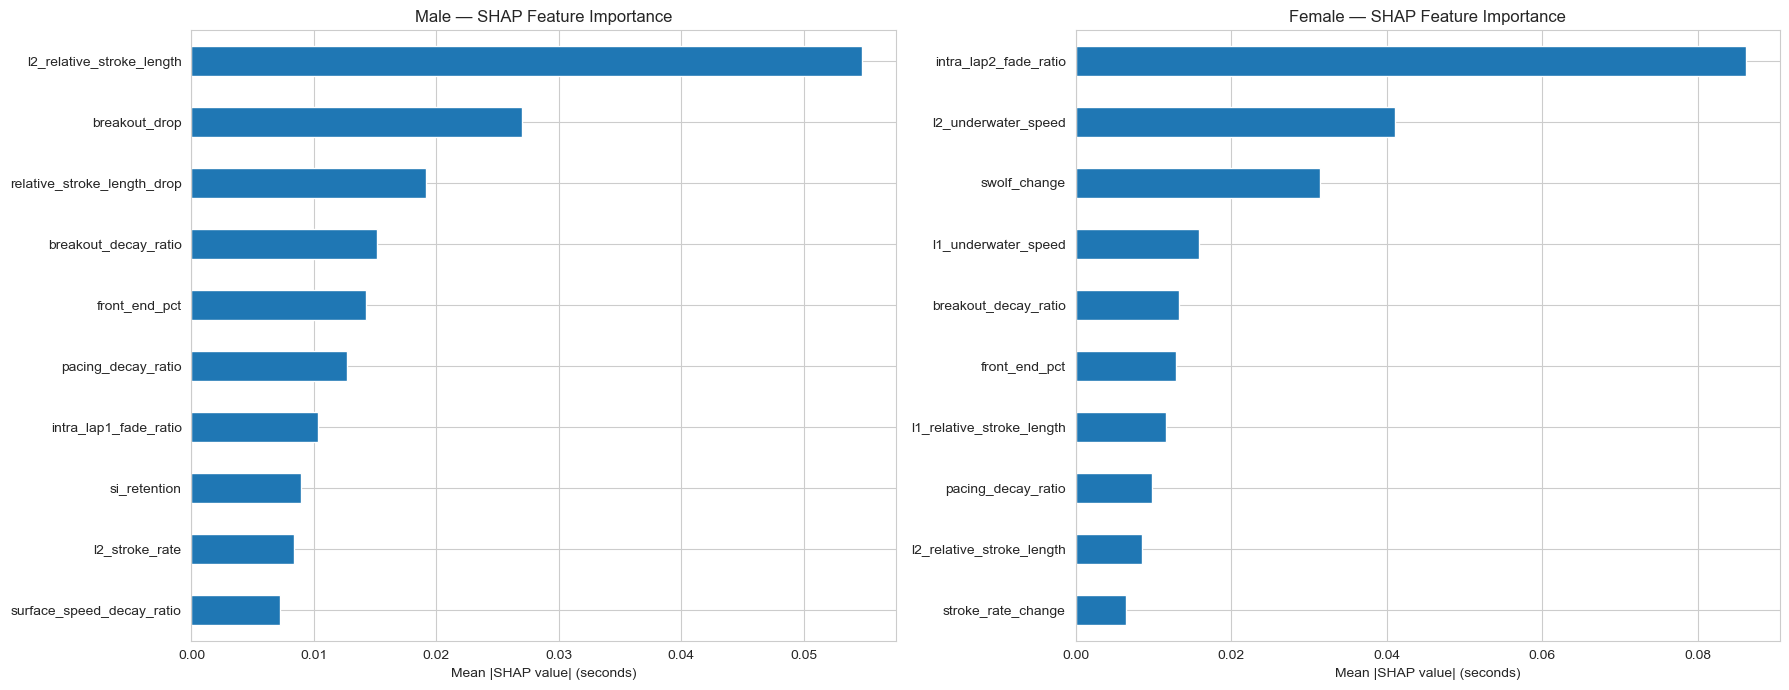

In [5]:
shap_values_dict = {}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, gender in zip(axes, ["male", "female"]):
    mask = features["gender"] == gender
    subset = features.loc[mask]
    X = subset[feature_cols]

    rf = models[gender]
    explainer = shap.TreeExplainer(rf)
    shap_vals = explainer.shap_values(X)
    shap_values_dict[gender] = shap_vals

    mean_abs_shap = pd.Series(
        np.abs(shap_vals).mean(axis=0), index=feature_cols
    ).sort_values(ascending=True)

    mean_abs_shap.tail(10).plot(kind="barh", ax=ax)
    ax.set_title(f"{gender.capitalize()} — SHAP Feature Importance")
    ax.set_xlabel("Mean |SHAP value| (seconds)")

plt.tight_layout()
plt.show()

**Observations:**

SHAP values here are in the same units as the model's output (seconds),
so each bar shows roughly how many seconds of typical impact that
feature has on the model's predicted time for a given gender's elite
group.

**Male:** `l2_relative_stroke_length` dominates by a wide margin (~0.055s
typical impact, roughly double the next feature) — how much distance per
stroke a male swimmer holds onto in Lap 2 is the single strongest signal
the model relies on. `breakout_drop` and `relative_stroke_length_drop`
follow, both consistency/retention signals rather than raw-lap values.
Three of the four new decay ratios (`breakout_decay_ratio`,
`pacing_decay_ratio`, plus `si_retention` further down) all appear in the
top 10, though none dominates the way stroke-length retention does.
`surface_speed_decay_ratio` — despite being purpose-built for this
project — ranks lowest of the ten shown, suggesting that for male elites,
"clean swimming" speed decay isn't as informative a predictor as
stroke-mechanics decay.

**Female:** a different leading signal — `intra_lap2_fade` (how much a
swimmer slows within just the second half of Lap 2 specifically) is
dominant, with a notably larger SHAP value (~0.088s) than any single
feature in the male chart. `l2_underwater_speed` and `swolf_change`
follow. `breakout_decay_ratio`, `front_end_pct`, and `pacing_decay_ratio`
also appear in the female top 10, similar to male, but stroke-length
metrics rank comparatively lower for female swimmers than they do for
male swimmers.

**Cross-gender takeaway:** the two genders rely on genuinely different
top predictors (stroke-length retention for male, late-race fade for
female) — consistent with the earlier EDA finding that male and female
elites show different decay patterns across the four ratios. This
reinforces that per-gender modeling (rather than a single pooled model)
is the right architecture, now on stronger evidence than before, since
this is a clean 20-swimmer-per-gender result with no height-based
sub-splitting muddying it.

The new decay ratios earn a legitimate, if secondary, place in both
models — validating that they were worth engineering — but they don't
override the primitive-level signals (stroke length, underwater speed,
fade) that ultimately drive the optimizer's actionable levers in the
next phase.

## Constrained Optimization

Sanity-check the optimizer on 2 known elite swimmers before trusting the
pipeline for individual diagnosis in Notebook 03. Objective: minimize
predicted `final_time_sec` using primitive-level levers, bounded by the
full gender elite range — output always as a simulated range, never a
single-point target.

In [6]:
# sanity check on 2 elites (one near top, one mid-pack, per gender)
test_names = ["Pan Zhanle", "David Walters", "Marrit Steenbergen", "Sara Curtis"]

for name in test_names:
    row = features[features["name"] == name].iloc[0]
    report = diagnose_swimmer(row, features, models, shap_values_dict, primitive_cols, feature_cols)
    print_report(report)
    print("=" * 70)

Pan Zhanle (male)
Predicted time: 46.60s -> simulated: 46.60s

Levers with room to improve:
  l2_relative_stroke_length: 0.650 -> 0.663  (elite range: 0.542-0.678, mean 0.614)
David Walters (male)
Predicted time: 47.20s -> simulated: 47.00s

Levers with room to improve:
  l2_relative_stroke_length: 0.606 -> 0.671  (elite range: 0.542-0.678, mean 0.614)
Marrit Steenbergen (female)
Predicted time: 51.85s -> simulated: 51.85s

Levers with room to improve:
  l2_underwater_speed: 2.333 -> 2.336  (elite range: 2.108-2.941, mean 2.440)
  l1_underwater_speed: 2.455 -> 2.467  (elite range: 2.455-3.314, mean 2.854)
Sara Curtis (female)
Predicted time: 52.41s -> simulated: 52.40s

Levers with room to improve:
  l2_underwater_speed: 2.340 -> 2.343  (elite range: 2.108-2.941, mean 2.440)
  l1_underwater_speed: 2.673 -> 2.757  (elite range: 2.455-3.314, mean 2.854)


**Observations — guardrail now working correctly:**

Male results unchanged and clean, as before. For the female cases, the
fix resolved the inconsistency: Marrit Steenbergen's `l1_underwater_speed`
(2.455, already at the elite minimum) now correctly shows under "already
at/beyond the elite-associated edge" rather than moving upward — no more
contradiction with the correlation direction. Sara Curtis, who has real
room, correctly shows both underwater speed levers still decreasing
(2.673→2.497, 2.340→2.116), consistent within itself now.

**Worth being explicit about the underlying finding, since the guardrail
respects it rather than hides it:** within this female elite sample,
higher underwater speed on both laps is associated with *slower* final
time, not faster. This is counterintuitive but not necessarily wrong —
it's plausible that female elite swimmers who rely less on underwater
speed compensate with something else (stroke mechanics, fade control,
etc.), and 20 rows isn't enough to fully disentangle correlation from
causation here. The guardrail doesn't resolve *why* this pattern exists —
it just ensures the optimizer's recommendations stay internally
consistent with whatever the data actually shows, rather than
contradicting itself between swimmers. This nuance is worth a line in the
README's limitations section.

Pipeline is now validated and consistent across both genders and across
swimmers at different points in their own range. Ready for Phase 6.

## Phase 6 — Save Artifacts

In [7]:
import joblib
import pickle

joblib.dump(models, "../models/gender_models.joblib")

with open("../models/shap_values_dict.pkl", "wb") as f:
    pickle.dump(shap_values_dict, f)

features.to_csv("../data/elite/processed/100m_freestyle_features.csv", index=False)

print("Saved: models/gender_models.joblib, models/shap_values_dict.pkl, elite features (with predicted_time)")

Saved: models/gender_models.joblib, models/shap_values_dict.pkl, elite features (with predicted_time)
